Silhouette Score : 0.29661157520664294


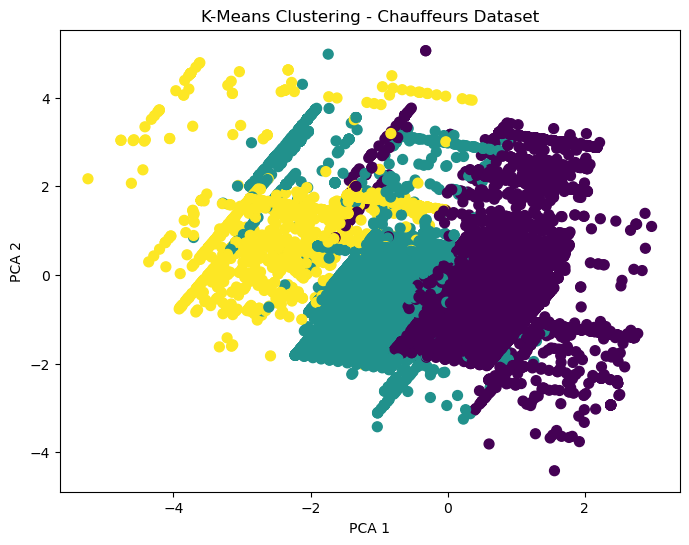

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Charger le dataset
df = pd.read_csv("Public_Chauffeurs_20260405.csv")

# 2. Sélection des colonnes utiles
df = df[['Renewed', 'Status', 'Driver Type', 'License Type', 'Sex', 'Chauffeur City']]

# 3. Encodage des variables catégorielles
for col in df.columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# 4. Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 5. K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# 6. Silhouette Score
score = silhouette_score(X_scaled, labels)
print("Silhouette Score :", score)

# 7. PCA pour visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 8. Visualisation
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', s=50)
plt.title("K-Means Clustering - Chauffeurs Dataset")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

Silhouette Score : 0.29661157520664294


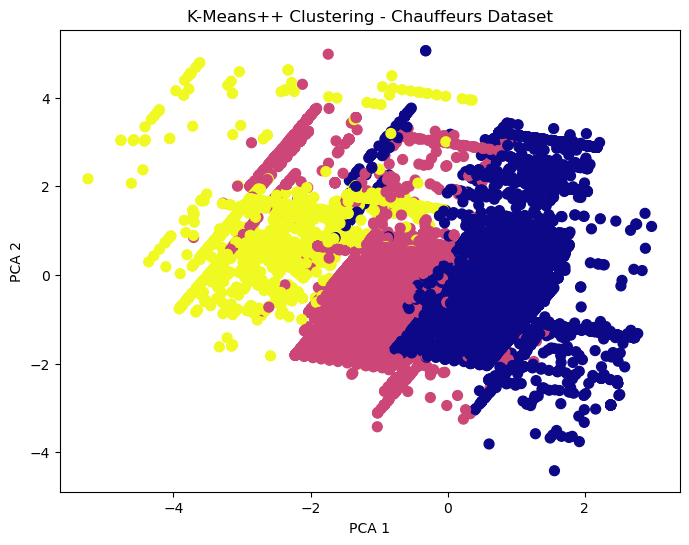

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Charger le dataset
df = pd.read_csv("Public_Chauffeurs_20260405.csv")

# 2. Sélection des colonnes utiles
df = df[['Renewed', 'Status', 'Driver Type', 'License Type', 'Sex', 'Chauffeur City']]

# 3. Encodage des variables catégorielles
for col in df.columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# 4. Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 5. K-Means++
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# 6. Silhouette Score
score = silhouette_score(X_scaled, labels)
print("Silhouette Score :", score)

# 7. PCA pour visualisation 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 8. Visualisation
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='plasma', s=50)

plt.title("K-Means++ Clustering - Chauffeurs Dataset")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

Silhouette Score : 0.4635397565850691


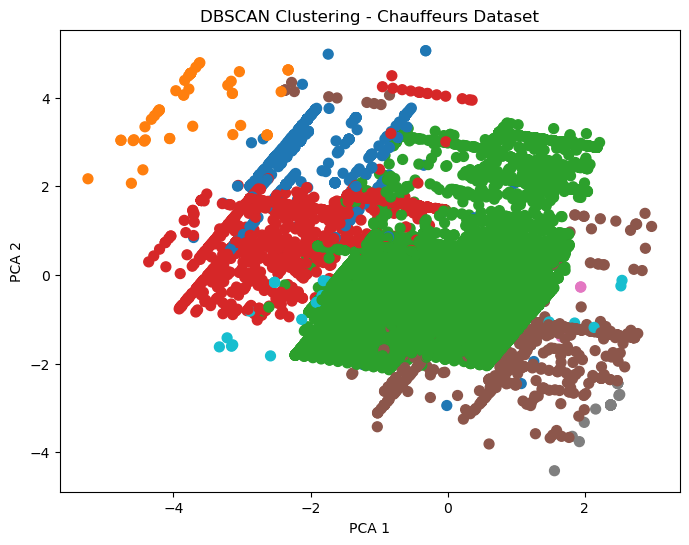

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Charger le dataset
df = pd.read_csv("Public_Chauffeurs_20260405.csv")

# Sélection des colonnes utiles
df = df[['Renewed', 'Status', 'Driver Type', 'License Type', 'Sex', 'Chauffeur City']]

# Encodage des variables catégorielles
for col in df.columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# Filtrer les bruits (-1)
mask = labels != -1

# Silhouette Score (uniquement si on a au moins 2 clusters)
if len(set(labels[mask])) > 1:
    score = silhouette_score(X_scaled[mask], labels[mask])
    print("Silhouette Score :", score)
else:
    print("Silhouette Score non calculable (pas assez de clusters)")

# PCA pour visualisation 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualisation
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab10', s=50)

plt.title("DBSCAN Clustering - Chauffeurs Dataset")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

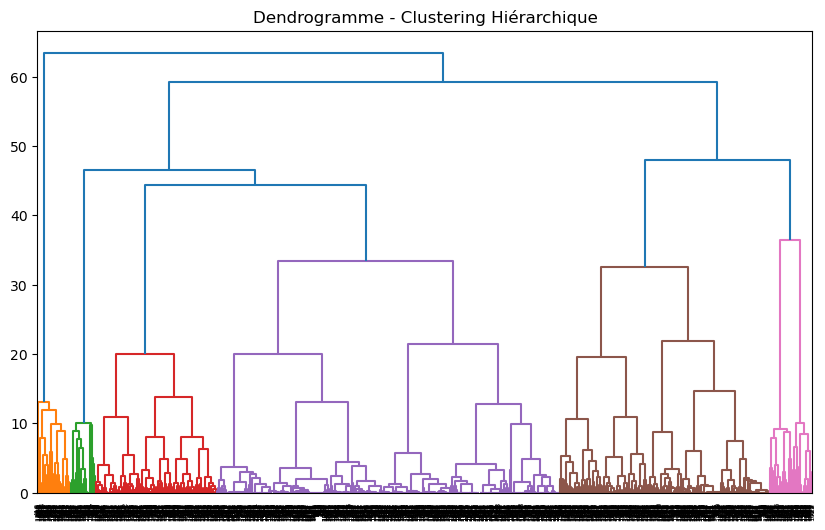

Silhouette Score (Hiérarchique) : 0.2904058117943365


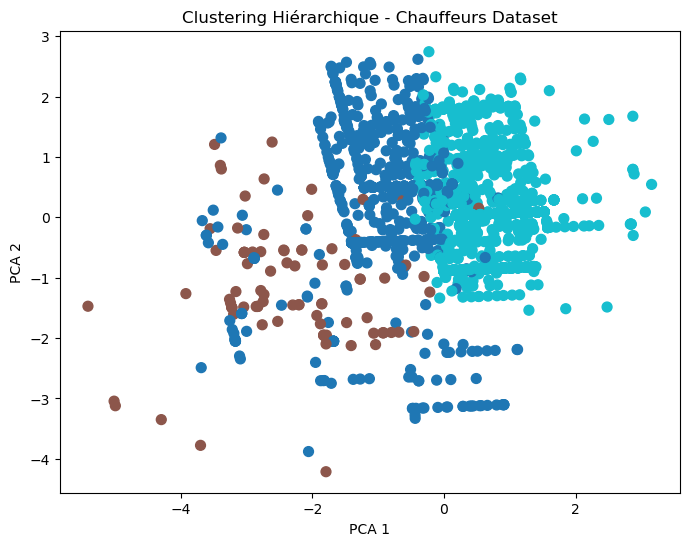

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Charger le dataset
df = pd.read_csv("Public_Chauffeurs_20260405.csv")

# 2. Sélection des colonnes utiles
df = df[['Renewed', 'Status', 'Driver Type', 'License Type', 'Sex', 'Chauffeur City']]

# 3. Encodage des variables catégorielles
for col in df.columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# 4. Échantillonnage (éviter lenteur)
df = df.sample(2000, random_state=42)

# 5. Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 6. Dendrogramme
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title("Dendrogramme - Clustering Hiérarchique")
plt.show()

# 7. Clustering hiérarchique
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = hc.fit_predict(X_scaled)

# 8. Silhouette Score
score = silhouette_score(X_scaled, labels)
print("Silhouette Score (Hiérarchique) :", score)

# 9. PCA (visualisation)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab10', s=50)

plt.title("Clustering Hiérarchique - Chauffeurs Dataset")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()